# 2. 각 오브젝트 탐지하기
- 박스, 선

감지된 사각형: 10개


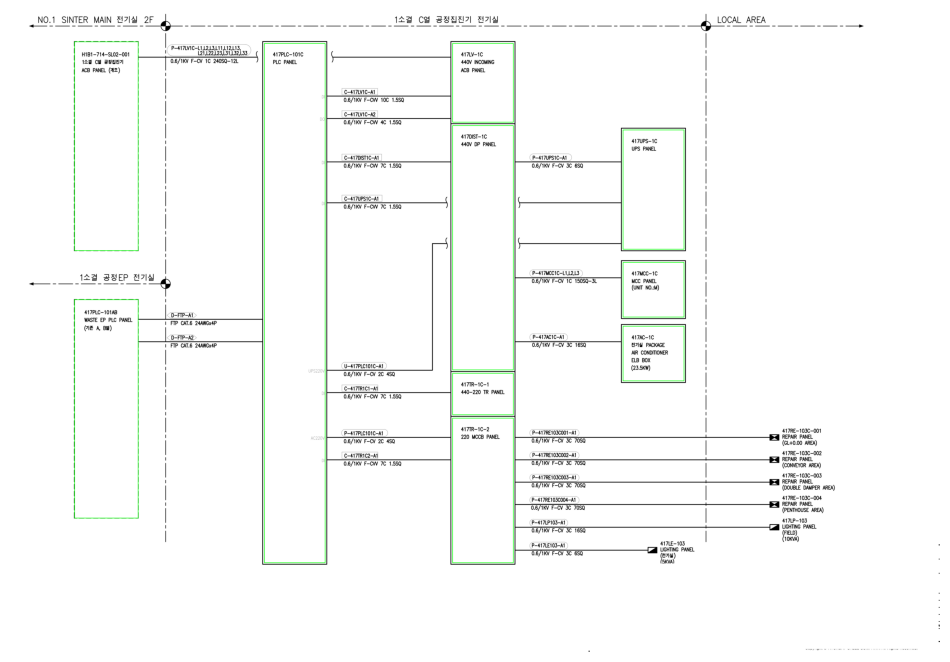

In [ ]:
"""
2-1. 네모 박스 탐지

Args:
    텍스트 제거하지 않은 이미지(output_remove_table.png) --> 네모 박스를 더 잘 탐지함

Returns:
    네모 박스 좌표 리스트

"""
import cv2
from matplotlib import pyplot as plt
from drawing_ocr_auto_zone_easy import DrawingOCRAutoZone

# 이미지 읽기
img_path = './output_v2/output_remove_table.png'
image = cv2.imread(img_path)

# OCR 없이 사각형 ㅇ
detector = DrawingOCRAutoZone(use_gpu=True).detector
rectangles = detector.detect_rectangles(img_path, text_regions=None)

# 사각형 시각화
for rect in rectangles:
    x1, y1, x2, y2 = rect['bbox']  # bbox 사용
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# OpenCV 이미지는 BGR이므로 RGB로 변환
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Notebook에서 표시
plt.figure(figsize=(12, 12))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


In [3]:
"""
2-1-2. 네모 박스 좌표 기록

위에서 눈으로 확인하고 맞으면 좌표 기록하기

"""
from pathlib import Path

output_dir = Path("./test_v1")
output_dir.mkdir(parents=True, exist_ok=True)

output_txt_path = './test_v1/rectangles_coords.txt'

with open(output_txt_path, 'w') as f:
    for rect in rectangles:
        x1, y1, x2, y2 = rect['bbox']
        f.write(f"{x1},{y1},{x2},{y2}\n")

print(f"좌표가 {output_txt_path}에 저장되었습니다.")

좌표가 ./test_v1/rectangles_coords.txt에 저장되었습니다.


---

In [4]:
"""
작업용 : 눈으로 확인하고 싶어서
"""
# import cv2
# import numpy as np
# from matplotlib import pyplot as plt


# draw_img_path = './output_v2/removed_text/output_remove_table.png'
# img = cv2.imread(draw_img_path)
# image_vis = img.copy()  # 시각화용 복사본

# border_thickness = 3  # 테두리 폭
# padding = 12           # bbox 확장 폭

# for rect in rectangles:
#     x1, y1, x2, y2 = rect['bbox']
    
#     # 좌표 확장
#     x1_exp, y1_exp = max(0, x1 - padding), max(0, y1 - padding)
#     x2_exp, y2_exp = min(img.shape[1], x2 + padding), min(img.shape[0], y2 + padding)
    
#     green = [0, 255, 0]
#     # 사각형 내부 전체 흰색으로 덮기
#     image_vis[y1_exp:y2_exp, x1_exp:x2_exp] = green

# plt.figure(figsize=(12,12))
# plt.imshow(cv2.cvtColor(image_vis, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()


'\n작업용 : 눈으로 확인하고 싶어서\n'

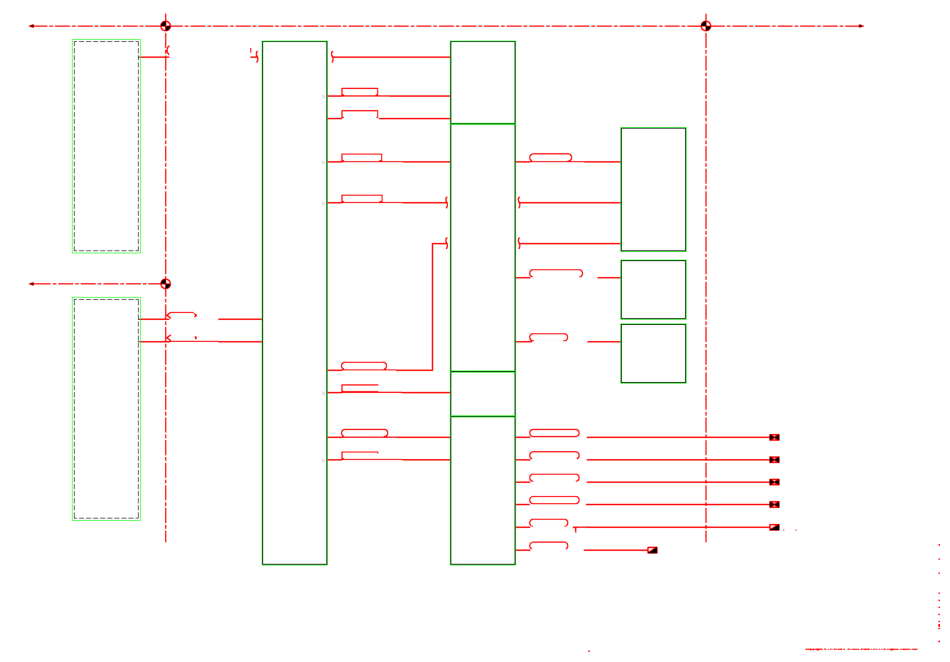

In [ ]:
"""
2-2. 박스와 선 구분(확인용)

"""
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. 이미지 읽기
draw_img_path = './output_v2/removed_text/output_remove_table.png'
img = cv2.imread(draw_img_path)
image_vis = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. 좌표 확장해서 새로운 네모(re_rectangles) 정의
padding = 12
re_rectangles = []
for rect in rectangles:
    x1, y1, x2, y2 = rect['bbox']
    x1_exp, y1_exp = max(0, x1 - padding), max(0, y1 - padding)
    x2_exp, y2_exp = min(img.shape[1], x2 + padding), min(img.shape[0], y2 + padding)
    re_rectangles.append({'bbox':[x1_exp, y1_exp, x2_exp, y2_exp]})

# 3. 마스크 생성 (re_rectangles 영역 제외)
mask = np.ones_like(gray, dtype=np.uint8) * 255  # 전체 흰색
for rect in re_rectangles:
    x1, y1, x2, y2 = rect['bbox']
    mask[y1:y2, x1:x2] = 0  # 박스 영역 제외

# 4. Edge 감지
blurred = cv2.GaussianBlur(gray, (3,3), 0)
edges = cv2.Canny(blurred, 50, 150)

# 5. 마스크 적용
edges_masked = cv2.bitwise_and(edges, edges, mask=mask)

# 6. Morphology로 선 연결
kernel = np.ones((3,3), np.uint8)
edges_closed = cv2.morphologyEx(cv2.dilate(edges_masked, kernel, iterations=1),
                                cv2.MORPH_CLOSE, kernel, iterations=1)

# 7. 시각화
line_img = img.copy()
line_img[edges_closed>0] = [0,0,255]  # 빨간 선
for rect in re_rectangles:
    x1, y1, x2, y2 = rect['bbox']
    cv2.rectangle(line_img, (x1, y1), (x2, y2), (0,255,0), 2)  # 초록 네모 표시

plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


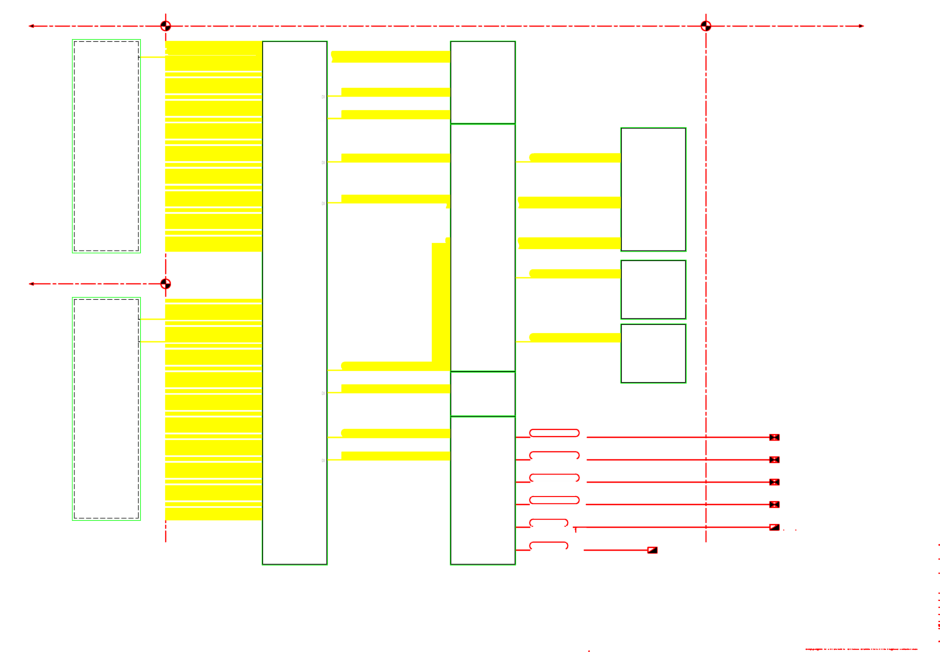

(1265, 160, 1594, 2788): [((1617, 210), (2210, 210), (2210, 160, 2539, 579)), ((1616, 211), (2210, 211), (2210, 160, 2539, 579)), ((1615, 212), (2210, 212), (2210, 160, 2539, 579)), ((1615, 213), (2210, 213), (2210, 160, 2539, 579)), ((1614, 214), (2210, 214), (2210, 160, 2539, 579)), ((1613, 215), (2210, 215), (2210, 160, 2539, 579)), ((1613, 216), (2210, 216), (2210, 160, 2539, 579)), ((1613, 217), (2210, 217), (2210, 160, 2539, 579)), ((1612, 218), (2210, 218), (2210, 160, 2539, 579)), ((1612, 219), (2210, 219), (2210, 160, 2539, 579)), ((1612, 220), (2210, 220), (2210, 160, 2539, 579)), ((1612, 221), (2210, 221), (2210, 160, 2539, 579)), ((1612, 222), (2210, 222), (2210, 160, 2539, 579)), ((1612, 223), (2210, 223), (2210, 160, 2539, 579)), ((1612, 224), (2210, 224), (2210, 160, 2539, 579)), ((1612, 225), (2210, 225), (2210, 160, 2539, 579)), ((1612, 226), (2210, 226), (2210, 160, 2539, 579)), ((1612, 227), (2210, 227), (2210, 160, 2539, 579)), ((1612, 228), (2210, 228), (2210, 160,

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def detect_horizontal_connections(re_rectangles, edges_img, step=1, y_margin=0.05):
    """
    각 박스에서 오른쪽으로 연결된 선 추적
    
    Args:
        re_rectangles: [{'bbox':[x1, y1, x2, y2]}, ...]
        edges_img: binary 선 이미지 (255=선)
        step: 오른쪽으로 이동할 간격
        y_margin: y 좌표 허용 범위 (선 높이)
    Returns:
        connections: {박스_bbox_tuple: [(start_pt, end_pt, target_box_bbox), ...], ...}
    """
    connections = {}
    h, w = edges_img.shape

    # 모든 박스 bbox 튜플 변환
    bbox_list = [tuple(r['bbox']) for r in re_rectangles]

    for rect in re_rectangles:
        x1, y1, x2, y2 = rect['bbox']
        rect_key = tuple(rect['bbox'])
        connections[rect_key] = []

        # 박스 오른쪽 가장자리 y 범위에서 선 시작점 탐지
        start_points = []
        for y in range(y1, y2):
            for x in range(x2, w):
                if edges_img[y, x] > 0:
                    start_points.append((x, y))
                    break

        # 각 시작점에서 오른쪽으로 이동
        for (sx, sy) in start_points:
            x_curr = sx
            y_curr = sy
            found_end = False

            while x_curr < w:
                # 현재 위치가 다른 박스 내부인지 확인
                inside_box = None
                for target_bbox in bbox_list:
                    if target_bbox == rect_key:
                        continue  # 자기 자신은 제외
                    tx1, ty1, tx2, ty2 = target_bbox

                    # y 방향으로 살짝 여유 두고 검사
                    if (tx1 <= x_curr <= tx2) and (ty1 - y_margin <= y_curr <= ty2 + y_margin):
                        # 선이 박스 왼쪽 가장자리부터 연결되는지 확인
                        box_left_x = tx1
                        # 박스 왼쪽 x 근처에서 edges_img가 연결되어 있어야 도착 박스로 판단
                        y_slice_start = max(0, ty1)
                        y_slice_end = min(h, ty2)
                        if np.any(edges_img[y_slice_start:y_slice_end, box_left_x:box_left_x+2] > 0):
                            inside_box = target_bbox
                        break

                if inside_box:
                    connections[rect_key].append(((sx, sy), (x_curr, y_curr), inside_box))
                    found_end = True
                    break

                # 오른쪽으로 이동
                x_curr += step

            # 도면 밖으로 나가면 패스
            if not found_end:
                continue

    return connections


# -------------------------
# 기존 데이터 사용
draw_img_path = './output_v2/removed_text/output_remove_table.png'
img = cv2.imread(draw_img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# re_rectangles는 이미 정의된 확장 bbox
# edges_closed도 이미 정의된 morphology 연결 선 이미지 사용

# 선 연결 탐지
connections = detect_horizontal_connections(re_rectangles, edges_closed)

# -------------------------
# 시각화
vis_img = img.copy()
# 빨간 선으로 edges
vis_img[edges_closed>0] = [0,0,255]

# 초록 박스 표시
for rect in re_rectangles:
    x1, y1, x2, y2 = rect['bbox']
    cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0,255,0), 2)

# 연결 선 시각화 (노랑)
for rect_bbox, conn_list in connections.items():
    for start_pt, end_pt, target_bbox in conn_list:
        cv2.line(vis_img, start_pt, end_pt, (0,255,255), 1)

plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# connections 출력 예시
for k, v in connections.items():
    print(f"{k}: {v}")
